In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## 구글 드라이브와 연동 (코랩 새로 켤 때마다 지워지기 땜에)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 구글 GPU 좀 써보자

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


## train_DS 와 test_DS 구경

In [ ]:
transform = transforms.ToTensor()  # 이미지를 PyTorch Tensor로 변환하는 변환기 정의

train_DS = datasets.MNIST(         # MNIST 학습용 데이터셋 객체 생성
    root='data',                  # 데이터를 저장할 경로를 'data' 폴더로 지정
    train=True,                   # 학습용 데이터셋을 불러옴
    download=True,                # 데이터가 없으면 자동으로 다운로드
    transform=transform           # 데이터를 불러올 때 transform 변환(이미지 → Tensor) 적용
)

test_DS = datasets.MNIST(         # MNIST 테스트용 데이터셋 객체 생성
    root='data',                  # 데이터를 저장할 경로를 'data' 폴더로 지정
    train=False,                  # 테스트용 데이터셋을 불러옴
    download=True,                # 데이터가 없으면 자동으로 다운로드
    transform=transform           # 데이터를 불러올 때 transform 변환(이미지 → Tensor) 적용
)

100.0%
100.0%
100.0%
100.0%


In [8]:
print(train_DS)
print(test_DS)
print(len(train_DS))
print(len(test_DS))

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()
60000
10000


In [ ]:
train_DS.classes # . 뒤에서 탭 하면 이것저것 볼 수 있는 게 뜬다

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [10]:
train_DS.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [11]:
train_DS.data.shape

torch.Size([60000, 28, 28])

In [12]:
train_DS.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

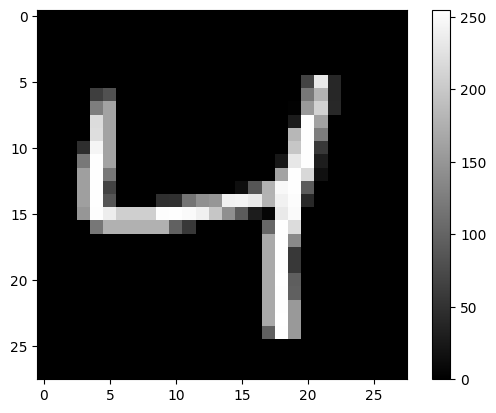

In [40]:
plt.imshow(train_DS.data[2], cmap="gray")
plt.colorbar()

In [14]:
print(train_DS.targets)
print(train_DS.targets.shape)

tensor([5, 0, 4,  ..., 5, 6, 8])
torch.Size([60000])


## DataLoader 구경

In [ ]:
# 한 번에 model에 입력되는 데이터(이미지)의 개수(배치 크기)를 정의
BATCH_SIZE = 32

# 학습 데이터셋(train_DS)을 DataLoader로 감싸서 배치 단위로 데이터를 공급하도록 만듦
# - batch_size : 한 배치에 들어가는 데이터 개수
# - shuffle=True : 에포크마다 데이터의 순서를 섞어서 모델이 데이터 순서에 의존하지 않도록 함
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)

# 테스트 데이터셋(test_DS)에 대해서도 동일하게 DataLoader 생성
# - 여기서도 shuffle=True를 사용하면, 실제 평가 때마다 데이터 순서가 랜덤하게 됨 (일반적으론 False로 하기도 함)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
train_DL.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

<class 'torch.Tensor'>
torch.Size([60000, 28, 28])
torch.uint8
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,

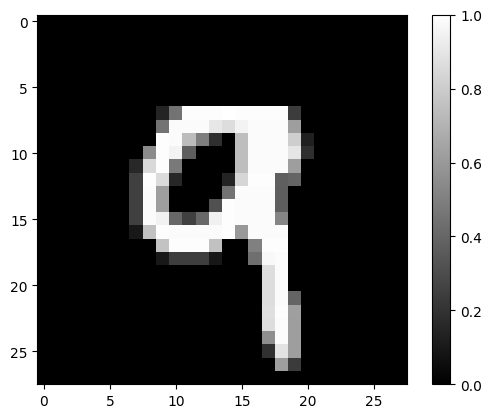

In [17]:
x_batch, y_batch = next(iter(train_DL)) # 데이터 한 국자 # next(iter(train_DS)) 는 한장만 꺼내기
# ToTensor 의 역할
# 1. tensor 로 바꾸고
# 2. 개채행열로 바꾸고
# 3. 0~1 사이로 바꾸고 (int -> float)
print(type(train_DS.data))
print(train_DS.data.shape)
print(train_DS.data.dtype)
print(train_DS.data[0])

print(type(x_batch))
print(x_batch.shape)
print(x_batch.dtype)
print(x_batch[0])

plt.imshow(x_batch[0].permute(1,2,0),cmap='gray')
plt.colorbar()
print(y_batch[0])

## 본격적으로 model 만들기!

In [18]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fcs = nn.Sequential(nn.Linear(28*28, 100),
                                 nn.ReLU(),
                                 nn.Linear(100, 10))
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.fcs(x)
        return x

In [19]:
# flatten 확인
x_batch, _ = next(iter(train_DL))
print(x_batch.shape)
flat_images = torch.flatten(x_batch)
print(flat_images.shape)
flat_images2 = torch.flatten(x_batch, start_dim=1)
print(flat_images2.shape)

torch.Size([32, 1, 28, 28])
torch.Size([25088])
torch.Size([32, 784])


In [20]:
model=MLP().to(DEVICE)
print(model)

x_batch, _ = next(iter(train_DL))
print(x_batch.shape)

model.eval()
with torch.no_grad():
    print(model(x_batch.to(DEVICE)).shape)

MLP(
  (fcs): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)
torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


## 모델 훈련시키기!

In [21]:
from torch import optim

LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

def Train(model, train_DL, criterion, optimizer, EPOCH):

    loss_history=[]
    NoT=len(train_DL.dataset) # The number of training data

    model.train() # train mode로 전환
    for ep in range(EPOCH):
        rloss = 0 # running loss
        for x_batch, y_batch in train_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # loss
            loss = criterion(y_hat, y_batch)
            # update
            optimizer.zero_grad() # gradient 누적을 막기 위한 초기화
            loss.backward() # backpropagation
            optimizer.step() # weight update
            # loss accumulation
            loss_b = loss.item() * x_batch.shape[0] # batch loss # BATCH_SIZE를 곱하면 마지막 18개도 32개를 곱하니까..
            rloss += loss_b # running loss
        # print loss
        loss_e = rloss/NoT # epoch loss
        loss_history += [loss_e]
        print(f"Epoch: {ep+1}, train loss: {loss_e:.3f}")
        print("-"*20)

    return loss_history

## Cross Entropy 확인 (왜 모델에 softmax를 안붙였을까?)



In [22]:
# cross entropy 구하는 여러가지 방법
import torch.nn.functional as F

y_hat = torch.randn(3, 5) # data는 세 개, 5 종류로 분류하는 문제 가정
print(y_hat) # 가로 축으로 합이 1이 아님, 즉, softmax 통과 전
y_batch = torch.randint(5, (3,))
print(y_batch)

# 방법 1
loss = F.cross_entropy(y_hat, y_batch) # softmax가 내장
print(loss)

# 방법 2
criterion = nn.CrossEntropyLoss() # softmax가 내장
print(criterion(y_hat,y_batch))

# 방법 3
soft = nn.Softmax(dim=1)
y_hat_soft = soft(y_hat)
print(y_hat_soft)
loss = 0
for i, val in enumerate(y_hat_soft):
    print(i,val)
    loss += -torch.log(val[y_batch[i]])
print(loss/3) # 평균이 내장되어있음을 알 수 있다

tensor([[-0.0344, -0.4394, -1.1081,  0.7368,  2.7493],
        [-0.2024, -0.4309, -0.5881,  1.0839,  1.0278],
        [-0.3176, -0.8212, -0.1075, -0.3514,  0.9864]])
tensor([1, 1, 0])
tensor(2.6377)
tensor(2.6377)
tensor([[0.0491, 0.0328, 0.0168, 0.1063, 0.7950],
        [0.1051, 0.0836, 0.0714, 0.3803, 0.3596],
        [0.1335, 0.0807, 0.1648, 0.1291, 0.4919]])
0 tensor([0.0491, 0.0328, 0.0168, 0.1063, 0.7950])
1 tensor([0.1051, 0.0836, 0.0714, 0.3803, 0.3596])
2 tensor([0.1335, 0.0807, 0.1648, 0.1291, 0.4919])
tensor(2.6377)


Epoch: 1, train loss: 0.313
--------------------
Epoch: 2, train loss: 0.144
--------------------
Epoch: 3, train loss: 0.098
--------------------
Epoch: 4, train loss: 0.075
--------------------
Epoch: 5, train loss: 0.059
--------------------


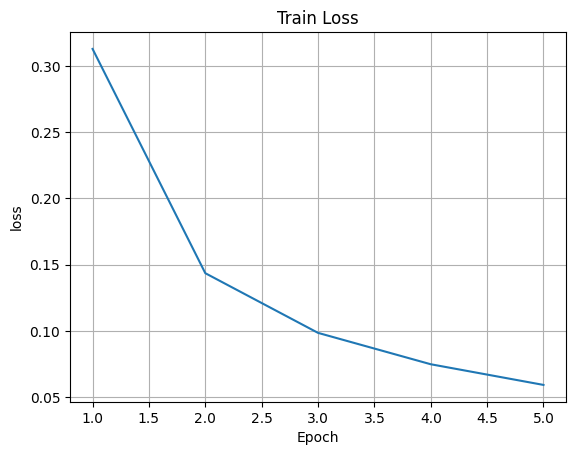

In [23]:
loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

plt.plot(range(1,EPOCH+1),loss_history)
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Train Loss")
plt.grid()

## 모델 저장하기 & 불러오기

In [24]:
# import os # 이건 내 필기용
# os.mkdir("/content/drive/MyDrive/Colab Notebooks/results") # 이건 내 필기용

save_model_path = "results/MLP.pt"
torch.save(model.state_dict(), save_model_path)

In [25]:
load_model = MLP().to(DEVICE)
load_model.load_state_dict(torch.load(save_model_path, map_location=DEVICE))
# map_location 있어야 GPU로 학습했던 거 현재 device로 불러올 수 있음

<All keys matched successfully>

## 모델 테스트하기

In [27]:
def Test(model, test_DL):
    model.eval() # test mode로 전환
    with torch.no_grad():
        rcorrect = 0
        for x_batch, y_batch in test_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # corrects accumulation
            pred = y_hat.argmax(dim=1)
            corrects_b = torch.sum(pred == y_batch).item() # torch.eq(pred, y_batch).sum().item()
            rcorrect += corrects_b
        accuracy_e = rcorrect/len(test_DL.dataset)*100
    print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({accuracy_e:.1f} %)")
    return round(accuracy_e,1)

In [28]:
Test(load_model, test_DL)

Test accuracy: 9759/10000 (97.6 %)


97.6

In [29]:
def Test_plot(model, test_DL):
    model.eval()
    with torch.no_grad():
        x_batch, y_batch = next(iter(test_DL))
        x_batch = x_batch.to(DEVICE)
        y_hat = model(x_batch)
        pred = y_hat.argmax(dim=1)

    x_batch = x_batch.to("cpu")
    # print(x_batch.shape)

    plt.figure(figsize=(8,4))
    for idx in range(6):
        plt.subplot(2,3, idx+1, xticks=[], yticks=[])
        plt.imshow(x_batch[idx].permute(1,2,0), cmap="gray")
        pred_class = test_DL.dataset.classes[pred[idx]]
        true_class = test_DL.dataset.classes[y_batch[idx]]
        plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class==true_class else "r")

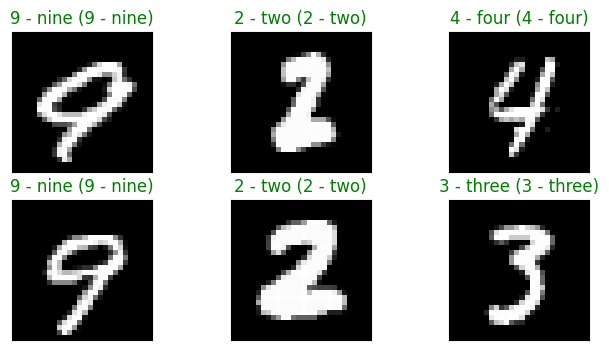

In [30]:
Test_plot(load_model, test_DL)

In [31]:
# 파라미터 수 구하기
def count_params(model):
    num = sum([p.numel() for p in model.parameters() if p.requires_grad])
    return num

In [32]:
print(count_params(load_model))

79510


## confusion matrix

In [33]:
def get_conf(model, test_DL):
    N = len(test_DL.dataset.classes)
    model.eval()
    with torch.no_grad():
        confusion = torch.zeros(N,N)
        for x_batch, y_batch in test_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # accuracy
            pred = y_hat.argmax(dim=1)

            confusion += torch.bincount(N * y_batch.cpu() + pred.cpu(), minlength=N**2).reshape(N, N)
            # confusion matrix는 무조건 10x10이 되어야 하는데 만약 마지막 label에 대해 예측을 모두 실패하면 100개보다 작아질 수 있기 때문에 minlength를 설정

    confusion = confusion.numpy()

    return confusion

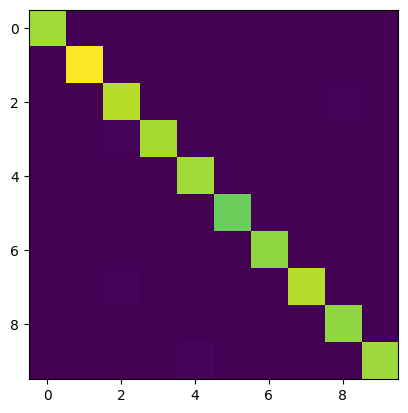

In [34]:
confusion = get_conf(load_model, test_DL)
plt.imshow(confusion)

In [35]:
import numpy as np

def plot_confusion_matrix(confusion, classes=None):
    N = confusion.shape[0]
    accuracy=np.trace(confusion)/np.sum(confusion) * 100

    # confusion = confusion/np.sum(confusion, axis=1)
    plt.figure(figsize=(10,7))
    plt.imshow(confusion, cmap="Blues")
    plt.title("confusion matrix")
    plt.colorbar()

    for i in range(N):
        for j in range(N):
            plt.text(j,i, round(confusion[i,j]),
                     horizontalalignment="center", fontsize=10,
                     color="white" if confusion[i,j] > np.max(confusion) / 1.5 else "black")

    if classes is not None:
        plt.xticks(range(N), classes)
        plt.yticks(range(N), classes)
    else:
        plt.xticks(range(N))
        plt.yticks(range(N))

    plt.xlabel(f"Predicted label \n accuracy = {accuracy:.1f} %")
    plt.ylabel("True label")

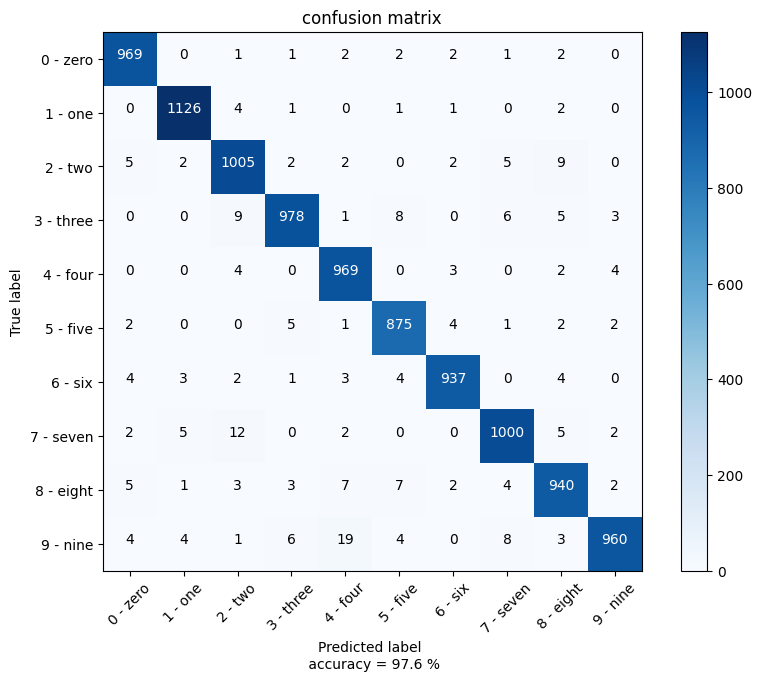

In [36]:
confusion = get_conf(load_model, test_DL)
plot_confusion_matrix(confusion, test_DS.classes)
plt.xticks(rotation=45);